Comparison of four classifiers (SVM, HGB, Random Forest, and Logistic Regression) evaluated on held-out test sets across two datasets, two feature sets, and two outlier conditions.

Primary metric: Balanced Accuracy (justified by 75:25 PD/healthy class imbalance)  
Secondary metric: Macro F1 

| Dataset | NaN strategy | Train | Test |
|---------|-------------|-------|------|
| A | Per-class group median imputation | 152 | 43 |
| B | Row deletion | 146 | 41 |

195 recordings across 31 subjects and 22 acoustic features

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

plt.rcParams.update({"figure.dpi": 150, "font.family": "sans-serif"})
sns.set_style("whitegrid")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

PALETTE = {
    "SVM": "#7F77DD",
    "HGB": "#1D9E75",
    "LR":  "#BA7517",
    "RF":  "#B07FC8",
}

Test-Set Results

Results consolidated from all model notebooks:
- SVM (SVM/svm_classification.ipynb) — nested CV + test evaluation
- HGB (HGB/HGB_pipeline.py and HGB_pipeline_without_outliers.py)
- RF (RF/random_forest_complete.ipynb — test set evaluation cell)
- LR (Logistic Regression/Logistic regression.ipynb) — Balanced Accuracy and Macro F1 derived analytically from Acc/Prec/Rec (pre-update outputs); the pipeline functions now compute these directly via `balanced_accuracy_score` and `f1_score(..., average='macro')` for future runs.

In [2]:
# fmt: off
RAW = [
    # Model   Dataset  Feature_Set        Outliers    Accuracy  Bal_Acc  Macro_F1
    # ── SVM ──────────────────────────────────────────────────────────────────────
    ("SVM",  "A",  "All",            "With",    0.837,   0.708,   0.743),
    ("SVM",  "A",  "All",            "Without", 0.872,   0.750,   0.794),
    ("SVM",  "B",  "All",            "With",    0.829,   0.708,   0.740),
    ("SVM",  "B",  "All",            "Without", 0.865,   0.750,   0.791),
    ("SVM",  "A",  "Jitter+Shimmer", "With",    0.977,   0.958,   0.970),
    ("SVM",  "A",  "Jitter+Shimmer", "Without", 0.897,   0.800,   0.843),
    ("SVM",  "B",  "Jitter+Shimmer", "With",    0.878,   0.792,   0.829),
    ("SVM",  "B",  "Jitter+Shimmer", "Without", 0.919,   0.850,   0.885),
    # ── HGB (macro F1 from re-run with f1_score added to evaluate_model) ─────────
    ("HGB",  "A",  "All",            "With",    0.884,   0.792,   0.831),
    ("HGB",  "A",  "Jitter+Shimmer", "With",    0.860,   0.750,   0.789),
    ("HGB",  "B",  "All",            "With",    0.854,   0.750,   0.786),
    ("HGB",  "B",  "Jitter+Shimmer", "With",    0.854,   0.750,   0.786),
    ("HGB",  "A",  "All",            "Without", 0.860,   0.750,   0.789),
    ("HGB",  "A",  "Jitter+Shimmer", "Without", 0.837,   0.734,   0.764),
    ("HGB",  "B",  "All",            "Without", 0.902,   0.833,   0.868),
    ("HGB",  "B",  "Jitter+Shimmer", "Without", 0.829,   0.733,   0.760),
    # ── RF (models/RF/random_forest_complete.ipynb, test-set evaluation cell) ────
    ("RF",   "A",  "All",            "With",    0.860,   0.750,   0.789),
    ("RF",   "B",  "All",            "With",    0.854,   0.750,   0.786),
    ("RF",   "A",  "All",            "Without", 0.897,   0.800,   0.843),
    ("RF",   "B",  "All",            "Without", 0.892,   0.800,   0.841),
    ("RF",   "A",  "Jitter+Shimmer", "With",    0.860,   0.750,   0.789),
    ("RF",   "B",  "Jitter+Shimmer", "With",    0.854,   0.750,   0.786),
    ("RF",   "A",  "Jitter+Shimmer", "Without", 0.897,   0.800,   0.843),
    ("RF",   "B",  "Jitter+Shimmer", "Without", 0.892,   0.800,   0.841),
    # ── LR (Logistic Regression/Logistic regression.ipynb) ───────────────────────
    # Balanced Acc + Macro F1 derived from Acc/Prec/Rec printed by the notebook.
    # With outliers:
    # A, All:  Acc=0.930, Prec=0.912, Rec=1.0 → TP=31,FP=3,TN=9  → BA=0.875
    ("LR",   "A",  "All",            "With",    0.930,   0.875,   0.906),
    # B, All:  Acc=0.878, Prec=0.853, Rec=1.0 → TP=29,FP=5,TN=7  → BA=0.792
    ("LR",   "B",  "All",            "With",    0.878,   0.792,   0.829),
    # A, J+S:  Acc=0.884, Prec=0.861, Rec=1.0 → TP=31,FP=5,TN=7  → BA=0.792
    ("LR",   "A",  "Jitter+Shimmer", "With",    0.884,   0.792,   0.831),
    # B, J+S:  Acc=0.829, Prec=0.844, Rec=0.931 → TP=27,FP=5,TN=7 → BA=0.757
    ("LR",   "B",  "Jitter+Shimmer", "With",    0.829,   0.757,   0.776),
    # Without outliers (23 recordings removed, new cells 4c2a7cf5/5827d598/83cfa5b1):
    # A, All:  Acc=0.919, Prec=0.900, Rec=1.0 → TP=27,FP=3,TN=7,n_h=10 → BA=0.850
    ("LR",   "A",  "All",            "Without", 0.919,   0.850,   0.885),
    # B, All:  Acc=0.914, Prec=0.893, Rec=1.0 → TP=25,FP=3,TN=7,n_h=10 → BA=0.850
    ("LR",   "B",  "All",            "Without", 0.914,   0.850,   0.883),
    # A, J+S:  Acc=0.892, Prec=0.871, Rec=1.0 → TP=27,FP=4,TN=6,n_h=10 → BA=0.800
    ("LR",   "A",  "Jitter+Shimmer", "Without", 0.892,   0.800,   0.841),
    # B, J+S:  Acc=0.829, Prec=0.852, Rec=0.920 → TP=23,FP=4,TN=6,n_h=10 → BA=0.760
    ("LR",   "B",  "Jitter+Shimmer", "Without", 0.829,   0.760,   0.776),
]
# fmt: on

df = pd.DataFrame(
    RAW,
    columns=["Model", "Dataset", "Feature_Set", "Outliers",
             "Accuracy", "Balanced_Acc", "Macro_F1"],
)

print(f"Total configurations: {len(df)}")
df

Total configurations: 32


,Model,Dataset,Feature_Set,Outliers,Accuracy,Balanced_Acc,Macro_F1
0,SVM,A,All,With,0.837,0.708,0.743
1,SVM,A,All,Without,0.872,0.750,0.794
2,SVM,B,All,With,0.829,0.708,0.740
3,SVM,B,All,Without,0.865,0.750,0.791
4,SVM,A,Jitter+Shimmer,With,0.977,0.958,0.970
5,SVM,A,Jitter+Shimmer,Without,0.897,0.800,0.843
6,SVM,B,Jitter+Shimmer,With,0.878,0.792,0.829
7,SVM,B,Jitter+Shimmer,Without,0.919,0.850,0.885
8,HGB,A,All,With,0.884,0.792,0.831
9,HGB,A,Jitter+Shimmer,With,0.860,0.750,0.789


Best Configuration per Model

In [3]:
# Best balanced accuracy row per model
best_rows = (
    df.sort_values("Balanced_Acc", ascending=False)
      .groupby("Model", sort=False)
      .first()
      .reset_index()
)

summary_df = (
    best_rows[["Model", "Balanced_Acc", "Macro_F1", "Accuracy",
               "Dataset", "Feature_Set", "Outliers"]]
    .rename(columns={
        "Balanced_Acc": "Best BA",
        "Macro_F1":     "Best Macro F1",
        "Accuracy":     "Best Accuracy",
        "Feature_Set":  "Feature Set",
    })
    .sort_values("Best BA", ascending=False)
    .set_index("Model")
)

print("Best test-set configuration per model (by Balanced Accuracy):")
summary_df

Best test-set configuration per model (by Balanced Accuracy):


,Best BA,Best Macro F1,Best Accuracy,Dataset,Feature Set,Outliers
Model,,,,,,
SVM,0.958,0.970,0.977,A,Jitter+Shimmer,With
LR,0.875,0.906,0.930,A,All,With
HGB,0.833,0.868,0.902,B,All,Without
RF,0.800,0.841,0.892,B,All,Without


In [4]:
# Balanced Accuracy pivot: all models × all configs
pivot_all = df.pivot_table(
    index="Model",
    columns=["Dataset", "Feature_Set", "Outliers"],
    values="Balanced_Acc",
    aggfunc="first",
)
pivot_all.columns = [
    f"{ds}, {'J+S' if fs == 'Jitter+Shimmer' else 'All'}, {out}"
    for ds, fs, out in pivot_all.columns
]
model_order = summary_df.index.tolist()
pivot_all = pivot_all.reindex(model_order)
print("Balanced Accuracy across all configurations (—  = not evaluated):")
pivot_all.round(3)

Balanced Accuracy across all configurations (—  = not evaluated):


,"A, All, With","A, All, Without","A, J+S, With","A, J+S, Without","B, All, With","B, All, Without","B, J+S, With","B, J+S, Without"
Model,,,,,,,,
SVM,0.708,0.75,0.958,0.800,0.708,0.750,0.792,0.850
LR,0.875,0.85,0.792,0.800,0.792,0.850,0.757,0.760
HGB,0.792,0.75,0.750,0.734,0.750,0.833,0.750,0.733
RF,0.750,0.80,0.750,0.800,0.750,0.800,0.750,0.800


Best Configuration per Model (Balanced Accuracy + Macro F1)

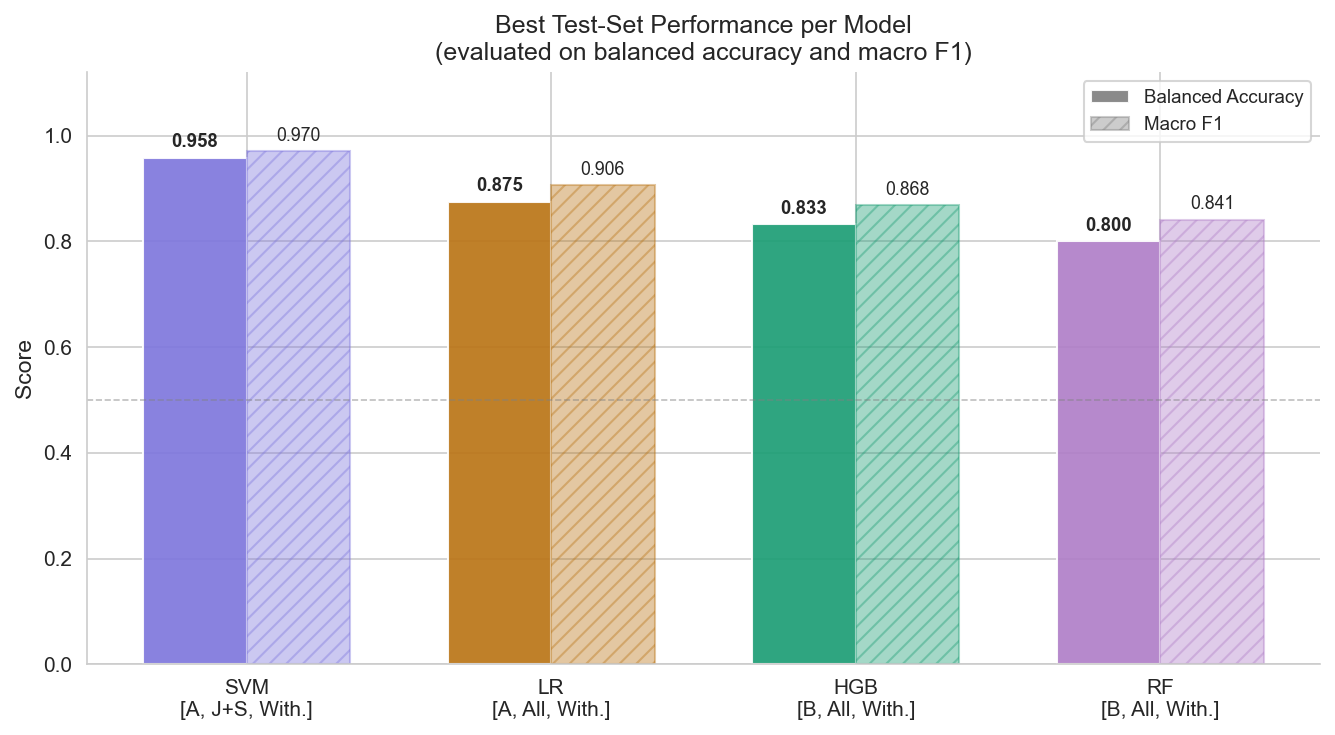

Saved → plots/model_comparison_best.png


In [5]:
models_ord = summary_df.index.tolist()  # sorted by best BA descending
x = np.arange(len(models_ord))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5))

# ── Balanced Accuracy bars ────────────────────────────────────────────────────
bars_ba = ax.bar(
    x - width / 2,
    summary_df["Best BA"].values,
    width,
    color=[PALETTE[m] for m in models_ord],
    alpha=0.92,
    edgecolor="white",
    label="Balanced Accuracy",
)

# ── Macro F1 bars (skip NaN) ──────────────────────────────────────────────────
for xi, m in zip(x, models_ord):
    f1 = summary_df.loc[m, "Best Macro F1"]
    if not np.isnan(f1):
        ax.bar(
            xi + width / 2, f1, width,
            color=PALETTE[m], alpha=0.40,
            hatch="///", edgecolor=PALETTE[m],
        )
        ax.text(xi + width / 2, f1 + 0.012, f"{f1:.3f}",
                ha="center", va="bottom", fontsize=8.5)
    else:
        ax.text(xi + width / 2, 0.03, "N/A",
                ha="center", va="bottom", fontsize=8, color="#888")

# ── Value labels on BA bars ───────────────────────────────────────────────────
for bar in bars_ba:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012, f"{h:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── X-tick labels: model name + best config ───────────────────────────────────
tick_labels = []
for m in models_ord:
    row = summary_df.loc[m]
    feat = "All" if row["Feature Set"] == "All" else "J+S"
    tick_labels.append(f"{m}\n[{row['Dataset']}, {feat}, {row['Outliers'][:4]}.]")

ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Best Test-Set Performance per Model\n(evaluated on balanced accuracy and macro F1)", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

patch_ba = mpatches.Patch(facecolor="grey", alpha=0.92, label="Balanced Accuracy")
patch_f1 = mpatches.Patch(facecolor="grey", alpha=0.40, hatch="///",
                           edgecolor="grey", label="Macro F1")
ax.legend(handles=[patch_ba, patch_f1], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_best.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {PLOTS_DIR / 'model_comparison_best.png'}")

Full Heatmap: Balanced Accuracy Across All Configurations

Rows = Model and Feature set 
Columns = Dataset and Outlier condition.  
White cells = configuration not evaluated

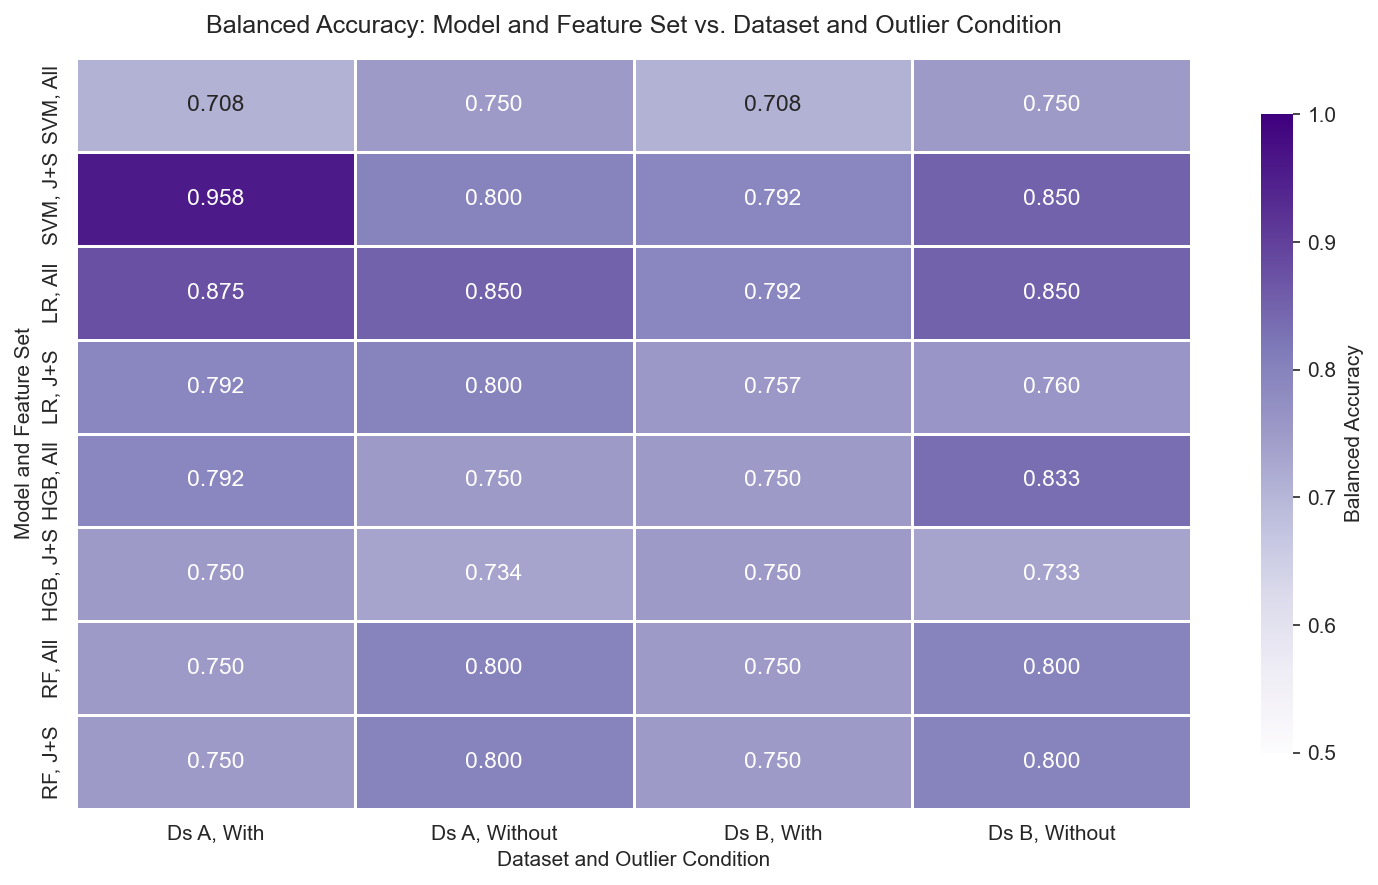

Saved → plots/model_comparison_heatmap.png


In [6]:
df_h = df.copy()
df_h["row_key"] = df_h["Model"] + ", " + df_h["Feature_Set"].str.replace(
    "Jitter+Shimmer", "J+S", regex=False
)
df_h["col_key"] = "Ds " + df_h["Dataset"] + ", " + df_h["Outliers"]

pivot_hm = df_h.pivot_table(
    index="row_key",
    columns="col_key",
    values="Balanced_Acc",
    aggfunc="first",
)

row_order = [
    "SVM, All", "SVM, J+S",
    "LR, All",  "LR, J+S",
    "HGB, All", "HGB, J+S",
    "RF, All",  "RF, J+S",
]
col_order = ["Ds A, With", "Ds A, Without", "Ds B, With", "Ds B, Without"]

pivot_hm = pivot_hm.reindex(
    index=[r for r in row_order if r in pivot_hm.index],
    columns=[c for c in col_order if c in pivot_hm.columns],
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_hm,
    ax=ax,
    cmap="Purples",
    annot=True,
    fmt=".3f",
    linewidths=0.6,
    linecolor="white",
    vmin=0.50,
    vmax=1.00,
    cbar_kws={"label": "Balanced Accuracy", "shrink": 0.85},
    annot_kws={"size": 11},
    mask=pivot_hm.isna(),
)

# Add "—" text to cells that have no data
for ri, row in enumerate(pivot_hm.index):
    for ci, col in enumerate(pivot_hm.columns):
        if pd.isna(pivot_hm.loc[row, col]):
            ax.text(ci + 0.5, ri + 0.5, "—", ha="center", va="center",
                    fontsize=13, color="#bbb")

ax.set_title(
    "Balanced Accuracy: Model and Feature Set vs. Dataset and Outlier Condition",
    fontsize=12, pad=12,
)
ax.set_xlabel("Dataset and Outlier Condition", fontsize=10)
ax.set_ylabel("Model and Feature Set", fontsize=10)
ax.tick_params(axis="both", labelsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {PLOTS_DIR / 'model_comparison_heatmap.png'}")

Dataset A vs. Dataset B

All models evaluated with all features and outliers included.  
Shows whether median imputation (A) or row deletion (B) benefits each classifier.

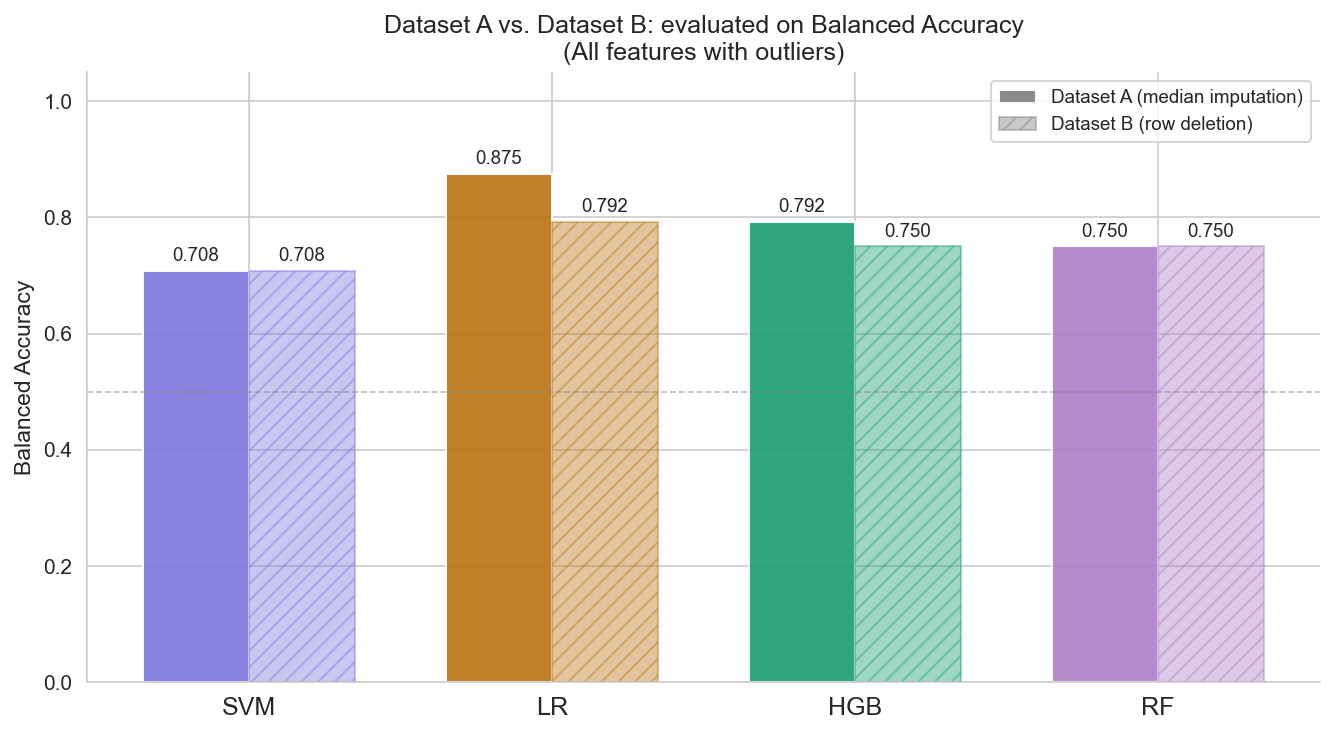

Saved → plots/model_comparison_dataset_ab.png


In [7]:
ab = df[(df["Feature_Set"] == "All") & (df["Outliers"] == "With")].copy()

# Align model order to global ranking
models_ab = [m for m in summary_df.index if m in ab["Model"].unique()]
x = np.arange(len(models_ab))
width = 0.35

def _get_ba(model, dataset):
    sub = ab[(ab["Model"] == model) & (ab["Dataset"] == dataset)]
    return sub["Balanced_Acc"].values[0] if len(sub) else np.nan

ba_a = [_get_ba(m, "A") for m in models_ab]
ba_b = [_get_ba(m, "B") for m in models_ab]

fig, ax = plt.subplots(figsize=(9, 5))

bars_a = ax.bar(
    x - width / 2, ba_a, width,
    color=[PALETTE[m] for m in models_ab],
    alpha=0.92, edgecolor="white",
)
bars_b = ax.bar(
    x + width / 2, ba_b, width,
    color=[PALETTE[m] for m in models_ab],
    alpha=0.42, hatch="///",
    edgecolor=[PALETTE[m] for m in models_ab],
)

for bars in [bars_a, bars_b]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.010,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_ab, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Balanced Accuracy", fontsize=11)
ax.set_title(
    "Dataset A vs. Dataset B: evaluated on Balanced Accuracy\n"
    "(All features with outliers)",
    fontsize=12,
)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

patch_a = mpatches.Patch(facecolor="grey", alpha=0.92,
                          label="Dataset A (median imputation)")
patch_b = mpatches.Patch(facecolor="grey", alpha=0.42, hatch="///",
                          edgecolor="grey", label="Dataset B (row deletion)")
ax.legend(handles=[patch_a, patch_b], fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_dataset_ab.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {PLOTS_DIR / 'model_comparison_dataset_ab.png'}")